In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# 1. Tải Dataset từ file local
print("--- 1. Loading Dataset ---")

file_path = "AirPassengers.csv"

# Đọc cột thứ 2 (Passengers)
df = pd.read_csv(file_path, usecols=[1])

# Chuyển sang numpy array float32
data = df.values.astype('float32')

print(df.head())
print("Shape:", data.shape)

2026-05-05 22:47:42.482472: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 22:47:42.483649: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 22:47:42.507801: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 22:47:42.508595: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 22:47:42.903361: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

--- 1. Loading Dataset ---
   #Passengers
0          112
1          118
2          132
3          129
4          121
Shape: (144, 1)



--- 2. Visualizing Raw Data ---


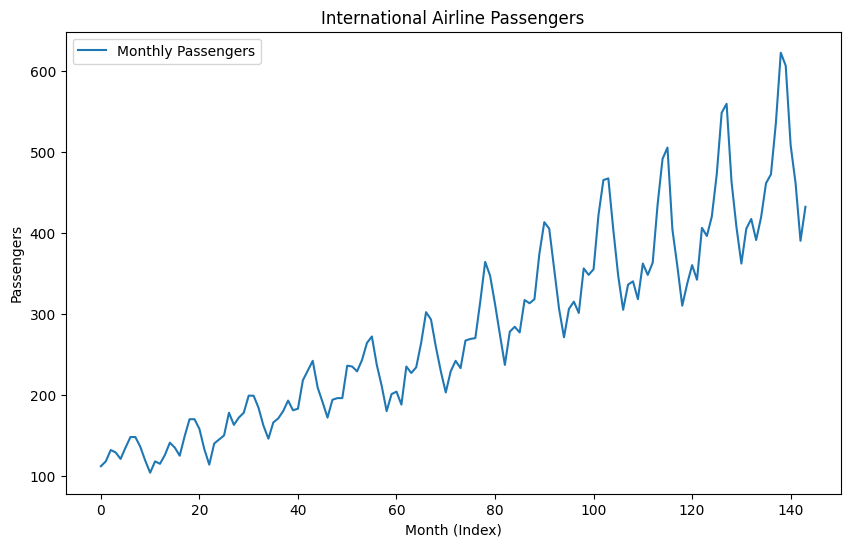

In [2]:
# 2. Visualize dữ liệu gốc
print("\n--- 2. Visualizing Raw Data ---")
plt.figure(figsize=(10, 6))
plt.plot(df, label='Monthly Passengers')
plt.title('International Airline Passengers')
plt.xlabel('Month (Index)')
plt.ylabel('Passengers')
plt.legend()
plt.show()


In [3]:
# 3. Tiền xử lý (Scaling & Windowing)
print("\n--- 3. Preprocessing ---")
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(data)

train_size = int(len(dataset) * 0.7)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

look_back = 1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))



--- 3. Preprocessing ---


In [4]:
# 4. Xây dựng mô hình LSTM cải tiến
print("\n--- 4. Building LSTM Model ---")
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(1, look_back)),
    LSTM(50),
    Dense(1)
])
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()



--- 4. Building LSTM Model ---


2026-05-05 22:47:44.408211: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-05 22:47:44.409766: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-05 22:47:44.412475: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 1, 50)             10400     
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 30651 (119.73 KB)
Trainable params: 30651 (119.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________



--- 5. Training Model ---


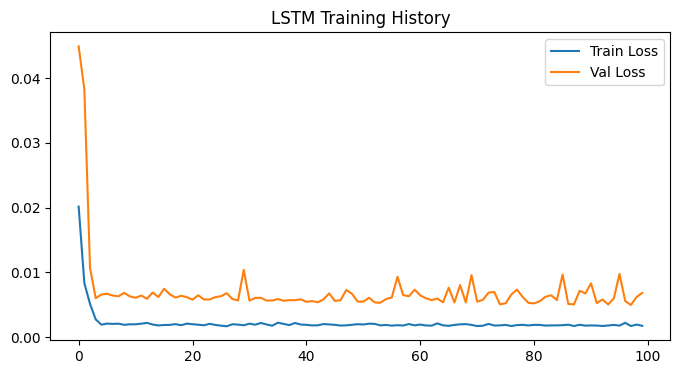

In [5]:
# 5. Huấn luyện (Training)
print("\n--- 5. Training Model ---")
# Tăng số epoch để mô hình học tốt hơn
history = model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=0, validation_split=0.1)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.legend()
plt.show()



--- 6. Predicting & Evaluating ---
4/4 [==============================] - 0s 801us/step


2/2 [==============================] - 0s 1ms/step
Train Score: 24.21 RMSE
Test Score: 65.41 RMSE


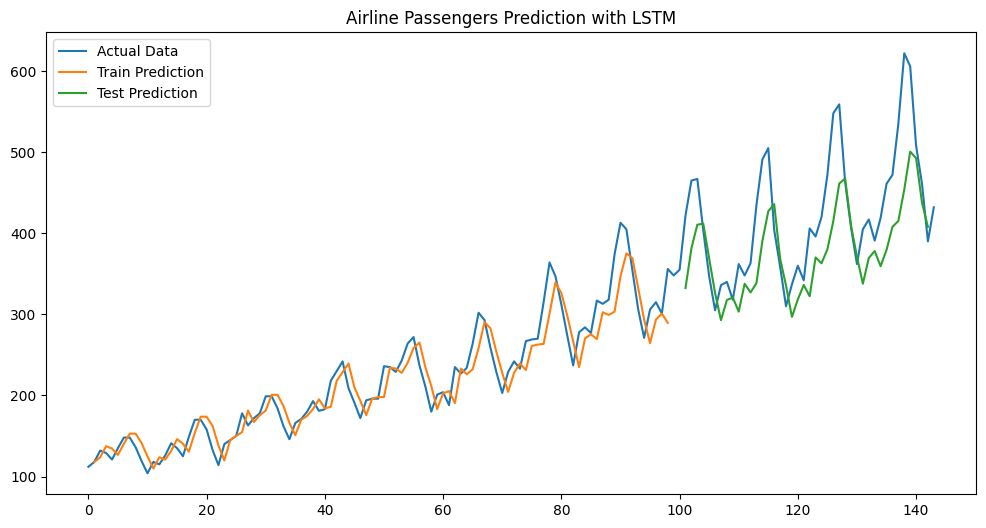

In [6]:
# 6. Dự báo & Đánh giá (Evaluation)
print("\n--- 6. Predicting & Evaluating ---")
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

trainPredict = scaler.inverse_transform(trainPredict)
trainY_orig = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY_orig = scaler.inverse_transform([testY])

from sklearn.metrics import mean_squared_error
import math
trainScore = math.sqrt(mean_squared_error(trainY_orig[0], trainPredict[:,0]))
print(f'Train Score: {trainScore:.2f} RMSE')
testScore = math.sqrt(mean_squared_error(testY_orig[0], testPredict[:,0]))
print(f'Test Score: {testScore:.2f} RMSE')

plt.figure(figsize=(12, 6))
plt.plot(scaler.inverse_transform(dataset), label='Actual Data')
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
plt.plot(trainPredictPlot, label='Train Prediction')
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict
plt.plot(testPredictPlot, label='Test Prediction')
plt.title('Airline Passengers Prediction with LSTM')
plt.legend()
plt.show()



--- 7. Forecasting next 12 months ---
1/1 [==============================] - 0s 10ms/step


1/1 [==============================] - 0s 11ms/step
Forecasted values for next 12 months:
 [388.45256757 357.52116812 334.35960703 316.37456763 302.03445444
 290.36864357 280.72819995 272.66086353 265.84057672 260.02566381
 255.03280328 250.72016986]


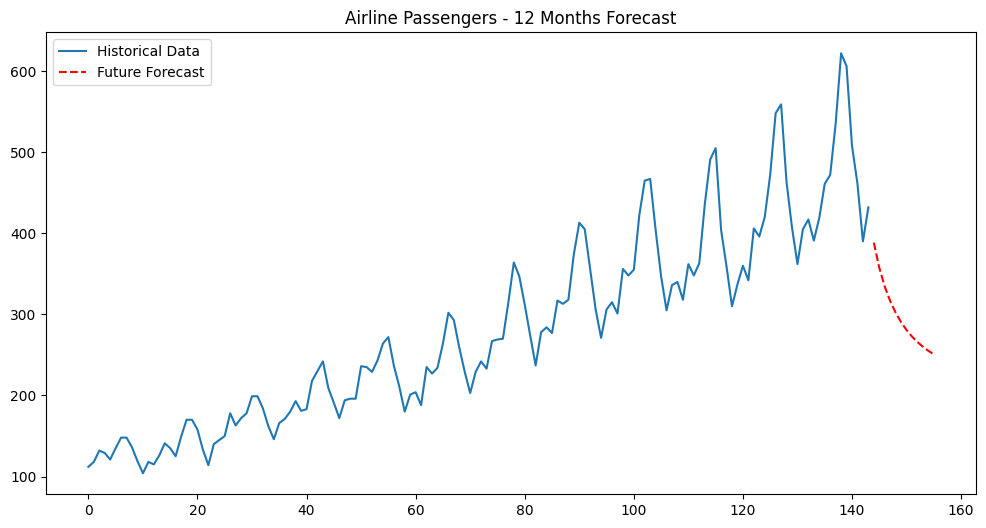

In [7]:
# 7. Dự báo tương lai (Future Forecasting)
print("\n--- 7. Forecasting next 12 months ---")
last_window = dataset[-look_back:].reshape(1, 1, look_back)
future_predictions = []

current_window = last_window
for i in range(12):
    pred = model.predict(current_window)
    future_predictions.append(pred[0, 0])
    # Update window: shift left and append new prediction
    new_val = pred
    current_window = np.array([np.append(current_window[0, 0, 1:], new_val)]).reshape(1, 1, look_back)

future_predictions = scaler.inverse_transform([future_predictions])
print("Forecasted values for next 12 months:\n", future_predictions[0])

# Vẽ biểu đồ bao gồm cả dự báo tương lai
plt.figure(figsize=(12, 6))
full_data = scaler.inverse_transform(dataset)
plt.plot(range(len(full_data)), full_data, label='Historical Data')
plt.plot(range(len(full_data), len(full_data) + 12), future_predictions[0], 'r--', label='Future Forecast')
plt.title('Airline Passengers - 12 Months Forecast')
plt.legend()
plt.show()